# Checkpoint 1 
## (Do not remove any comments that start with"# @@@".) 

Reminder: 

- You are being evaluated for completion and effort in this checkpoint. 
- Avoid manual labor / hard coding as much as possible, everything we've taught you so far are meant to simplify and automate your process.
- Please do not remove any comment that starts with: "# @@@". 

We will be working with the same `states_edu.csv` that you should already be familiar with from the tutorial.

We investigated Grade 8 reading score in the tutorial. For this checkpoint, you are asked to investigate another test. Here's an overview:

* Choose a specific response variable to focus on
>Grade 4 Math, Grade 4 Reading, Grade 8 Math
* Pick or create features to use
>Will all the features be useful in predicting test score? Are some more important than others? Should you standardize, bin, or scale the data?
* Explore the data as it relates to that test
>Create at least 2 visualizations (graphs), each with a caption describing the graph and what it tells us about the data
* Create training and testing data
>Do you want to train on all the data? Only data from the last 10 years? Only Michigan data?
* Train a ML model to predict outcome 
>Define what you want to predict, and pick a model in sklearn to use (see sklearn <a href="https://scikit-learn.org/stable/modules/linear_model.html">regressors</a>).


Include comments throughout your code! Every cleanup and preprocessing task should be documented.


<h2> Data Cleanup </h2>

Import `numpy`, `pandas`, and `matplotlib`.

(Feel free to import other libraries!)

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Load in the "states_edu.csv" dataset and take a look at the head of the data

In [52]:
df = pd.read_csv('../data/states_edu.csv')

df.head()

,PRIMARY_KEY,STATE,YEAR,ENROLL,TOTAL_REVENUE,FEDERAL_REVENUE,STATE_REVENUE,LOCAL_REVENUE,TOTAL_EXPENDITURE,INSTRUCTION_EXPENDITURE,...,GRADES_4_G,GRADES_8_G,GRADES_12_G,GRADES_1_8_G,GRADES_9_12_G,GRADES_ALL_G,AVG_MATH_4_SCORE,AVG_MATH_8_SCORE,AVG_READING_4_SCORE,AVG_READING_8_SCORE
0,1992_ALABAMA,ALABAMA,1992,NaN,2678885.0,304177.0,1659028.0,715680.0,2653798.0,1481703.0,...,57948.0,58025.0,41167.0,NaN,NaN,731634.0,208.0,252.0,207.0,NaN
1,1992_ALASKA,ALASKA,1992,NaN,1049591.0,106780.0,720711.0,222100.0,972488.0,498362.0,...,9748.0,8789.0,6714.0,NaN,NaN,122487.0,NaN,NaN,NaN,NaN
2,1992_ARIZONA,ARIZONA,1992,NaN,3258079.0,297888.0,1369815.0,1590376.0,3401580.0,1435908.0,...,55433.0,49081.0,37410.0,NaN,NaN,673477.0,215.0,265.0,209.0,NaN
3,1992_ARKANSAS,ARKANSAS,1992,NaN,1711959.0,178571.0,958785.0,574603.0,1743022.0,964323.0,...,34632.0,36011.0,27651.0,NaN,NaN,441490.0,210.0,256.0,211.0,NaN
4,1992_CALIFORNIA,CALIFORNIA,1992,NaN,26260025.0,2072470.0,16546514.0,7641041.0,27138832.0,14358922.0,...,418418.0,363296.0,270675.0,NaN,NaN,5254844.0,208.0,261.0,202.0,NaN


You should always familiarize yourself with what each column in the dataframe represents. Read about the states_edu dataset here: https://www.kaggle.com/noriuk/us-education-datasets-unification-project

Use this space to rename columns, deal with missing data, etc. _(optional)_

In [53]:
#print(df.columns) used to get original column names

# Renaming columns for easier access
df.rename({
    'PRIMARY_KEY':'Primary Key',
    'STATE':'State',
    'YEAR':'Year',
    'ENROLL':'Enroll',
    'TOTAL_REVENUE':'Total Revenue',
    'FEDERAL_REVENUE':'Federal Revenue',
    'STATE_REVENUE':'State Revenue',
    'LOCAL_REVENUE':'Local Revenue',
    'TOTAL_EXPENDITURE':'Total Expenditure',
    'INSTRUCTION_EXPENDITURE':'Instruction Expenditure',
    'SUPPORT_SERVICES_EXPENDITURE':'Support Services Expenditure',
    'OTHER_EXPENDITURE':'Other Expenditure',
    'CAPITAL_OUTLAY_EXPENDITURE':'Capital Outlay Expenditure',
    'ENROLL_PREK':'Enroll PREK',
    'ENROLL_KINDER':'Enroll KG',
    'ENROLL_4':'Enroll 4',
    'ENROLL_8':'Enroll 8',
    'ENROLL_12':'Enroll 12',
    'ENROLL_PRIMARY':'Enroll Primary',
    'ENROLL_HS':'Enroll HS',
    'ENROLL_ALL':'Enroll All',
    'AVG_MATH_4_SCORE':'Avg Math 4 Score',
    'AVG_MATH_8_SCORE':'Avg Math 8 Score',
    'AVG_READING_4_SCORE':'Avg Reading 4 Score',
    'AVG_READING_8_SCORE':'Avg Reading 8 Score'
    },axis=1,inplace=True)

# Checking for missing values
df.isna().sum()

# I am leaving missing values for now and will adress them later if needed
df

,Primary Key,State,Year,Enroll,Total Revenue,Federal Revenue,State Revenue,Local Revenue,Total Expenditure,Instruction Expenditure,...,GRADES_4_G,GRADES_8_G,GRADES_12_G,GRADES_1_8_G,GRADES_9_12_G,GRADES_ALL_G,Avg Math 4 Score,Avg Math 8 Score,Avg Reading 4 Score,Avg Reading 8 Score
0,1992_ALABAMA,ALABAMA,1992,NaN,2678885.0,304177.0,1659028.0,715680.0,2653798.0,1481703.0,...,57948.0,58025.0,41167.0,NaN,NaN,731634.0,208.0,252.0,207.0,NaN
1,1992_ALASKA,ALASKA,1992,NaN,1049591.0,106780.0,720711.0,222100.0,972488.0,498362.0,...,9748.0,8789.0,6714.0,NaN,NaN,122487.0,NaN,NaN,NaN,NaN
2,1992_ARIZONA,ARIZONA,1992,NaN,3258079.0,297888.0,1369815.0,1590376.0,3401580.0,1435908.0,...,55433.0,49081.0,37410.0,NaN,NaN,673477.0,215.0,265.0,209.0,NaN
3,1992_ARKANSAS,ARKANSAS,1992,NaN,1711959.0,178571.0,958785.0,574603.0,1743022.0,964323.0,...,34632.0,36011.0,27651.0,NaN,NaN,441490.0,210.0,256.0,211.0,NaN
4,1992_CALIFORNIA,CALIFORNIA,1992,NaN,26260025.0,2072470.0,16546514.0,7641041.0,27138832.0,14358922.0,...,418418.0,363296.0,270675.0,NaN,NaN,5254844.0,208.0,261.0,202.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1710,2019_VIRGINIA,VIRGINIA,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,247.0,287.0,224.0,262.0
1711,2019_WASHINGTON,WASHINGTON,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,240.0,286.0,220.0,266.0
1712,2019_WEST_VIRGINIA,WEST_VIRGINIA,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,231.0,272.0,213.0,256.0
1713,2019_WISCONSIN,WISCONSIN,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,242.0,289.0,220.0,267.0


<h2>Exploratory Data Analysis (EDA) </h2>

Chosen one of Grade 4 Reading, Grade 4 Math, or Grade 8 Math to focus on: *ENTER YOUR CHOICE HERE*

How many years of data are logged in our dataset? 

In [54]:
# @@@ 1
# Your Code

print(df['Year'].unique())

print("\nNumber of Unique Years:")
df['Year'].nunique()

[1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005
 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 1986 1987 1988
 1989 1990 1991 2017 2019]

Number of Unique Years:


33

Let's compare Michigan to Ohio. Which state has the higher average across all years in the test you chose?

In [55]:
# @@@ 2

avg_math8_by_state = df.groupby('State')['Avg Math 8 Score'].mean()

avg_math8_by_state

avg_math8_by_state.loc[['MICHIGAN', 'OHIO']].sort_values(ascending=False)

State
OHIO        282.250000
MICHIGAN    276.166667
Name: Avg Math 8 Score, dtype: float64

Find the average for your chosen test across all states in 2019

In [56]:
# @@@ 3

avg_math8_2019 = df[df['Year'] == 2019].groupby('State')['Avg Math 8 Score'].mean()

print(avg_math8_2019)

print(f"\nAverage math 8 score across all states in 2019: {avg_math8_2019.mean().round(2)}")

State
ALABAMA                 269.0
ALASKA                  274.0
ARIZONA                 280.0
ARKANSAS                274.0
CALIFORNIA              276.0
COLORADO                285.0
CONNECTICUT             286.0
DELAWARE                277.0
DISTRICT_OF_COLUMBIA    269.0
DODEA                   292.0
FLORIDA                 279.0
GEORGIA                 279.0
HAWAII                  275.0
IDAHO                   286.0
ILLINOIS                283.0
INDIANA                 286.0
IOWA                    282.0
KANSAS                  282.0
KENTUCKY                278.0
LOUISIANA               272.0
MAINE                   282.0
MARYLAND                280.0
MASSACHUSETTS           294.0
MICHIGAN                280.0
MINNESOTA               291.0
MISSISSIPPI             274.0
MISSOURI                281.0
MONTANA                 284.0
NATIONAL                282.0
NEBRASKA                285.0
NEVADA                  274.0
NEW_HAMPSHIRE           287.0
NEW_JERSEY              292.0
NEW_

For each state, find a maximum value for your chosen test score

In [57]:
# @@@ 4

math8_by_state = df.groupby('State')['Avg Math 8 Score'].max()


#print(avg_math8_by_state.sort_values(ascending=False).head(10))
math8_by_state.sort_values(ascending=False)

State
MASSACHUSETTS           301.0
NEW_JERSEY              296.0
NEW_HAMPSHIRE           296.0
VERMONT                 295.0
MINNESOTA               295.0
NORTH_DAKOTA            293.0
DODEA                   293.0
MONTANA                 293.0
COLORADO                292.0
SOUTH_DAKOTA            291.0
TEXAS                   290.0
WASHINGTON              290.0
VIRGINIA                290.0
KANSAS                  290.0
PENNSYLVANIA            290.0
OHIO                    290.0
WYOMING                 289.0
CONNECTICUT             289.0
WISCONSIN               289.0
MAINE                   289.0
MARYLAND                288.0
NEBRASKA                288.0
INDIANA                 288.0
UTAH                    287.0
IDAHO                   287.0
NORTH_CAROLINA          286.0
MISSOURI                286.0
IOWA                    286.0
NATIONAL                285.0
ILLINOIS                285.0
OREGON                  285.0
DELAWARE                284.0
RHODE_ISLAND            284.0
ALAS

*Refer to the `Grouping and Aggregating` section in Tutorial 0 if you are stuck.

<h2> Feature Engineering </h2>

After exploring the data, you can choose to modify features that you would use to predict the performance of the students on your chosen response variable. 

You can also create your own features. For example, perhaps you figured that maybe a state's expenditure per student may affect their overall academic performance so you create a expenditure_per_student feature.

Use this space to modify or create features.

In [58]:
# @@@ 5

print(df.columns)

df['Total Expenditure Per Grade 8 Enrollee'] = df['Total Expenditure'] / df['GRADES_8_G']

df

Index(['Primary Key', 'State', 'Year', 'Enroll', 'Total Revenue',
       'Federal Revenue', 'State Revenue', 'Local Revenue',
       'Total Expenditure', 'Instruction Expenditure',
       'Support Services Expenditure', 'Other Expenditure',
       'Capital Outlay Expenditure', 'GRADES_PK_G', 'GRADES_KG_G',
       'GRADES_4_G', 'GRADES_8_G', 'GRADES_12_G', 'GRADES_1_8_G',
       'GRADES_9_12_G', 'GRADES_ALL_G', 'Avg Math 4 Score', 'Avg Math 8 Score',
       'Avg Reading 4 Score', 'Avg Reading 8 Score'],
      dtype='str')


,Primary Key,State,Year,Enroll,Total Revenue,Federal Revenue,State Revenue,Local Revenue,Total Expenditure,Instruction Expenditure,...,GRADES_8_G,GRADES_12_G,GRADES_1_8_G,GRADES_9_12_G,GRADES_ALL_G,Avg Math 4 Score,Avg Math 8 Score,Avg Reading 4 Score,Avg Reading 8 Score,Total Expenditure Per Grade 8 Enrollee
0,1992_ALABAMA,ALABAMA,1992,NaN,2678885.0,304177.0,1659028.0,715680.0,2653798.0,1481703.0,...,58025.0,41167.0,NaN,NaN,731634.0,208.0,252.0,207.0,NaN,45.735424
1,1992_ALASKA,ALASKA,1992,NaN,1049591.0,106780.0,720711.0,222100.0,972488.0,498362.0,...,8789.0,6714.0,NaN,NaN,122487.0,NaN,NaN,NaN,NaN,110.648310
2,1992_ARIZONA,ARIZONA,1992,NaN,3258079.0,297888.0,1369815.0,1590376.0,3401580.0,1435908.0,...,49081.0,37410.0,NaN,NaN,673477.0,215.0,265.0,209.0,NaN,69.305434
3,1992_ARKANSAS,ARKANSAS,1992,NaN,1711959.0,178571.0,958785.0,574603.0,1743022.0,964323.0,...,36011.0,27651.0,NaN,NaN,441490.0,210.0,256.0,211.0,NaN,48.402488
4,1992_CALIFORNIA,CALIFORNIA,1992,NaN,26260025.0,2072470.0,16546514.0,7641041.0,27138832.0,14358922.0,...,363296.0,270675.0,NaN,NaN,5254844.0,208.0,261.0,202.0,NaN,74.701709
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1710,2019_VIRGINIA,VIRGINIA,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,247.0,287.0,224.0,262.0,NaN
1711,2019_WASHINGTON,WASHINGTON,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,240.0,286.0,220.0,266.0,NaN
1712,2019_WEST_VIRGINIA,WEST_VIRGINIA,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,231.0,272.0,213.0,256.0,NaN
1713,2019_WISCONSIN,WISCONSIN,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,242.0,289.0,220.0,267.0,NaN


Feature engineering justification: **<BRIEFLY DESCRIBE WHY YOU MADE THE CHANGES THAT YOU DID\>**

Total expenditure on its own is dominated by state size, for example California spends far more in absolute dollars than smaller states simply because they have more students. That makes raw expenditures a poor predictor of individual student outcome. By dividing by GRADES_8_G, I can get a per-student spending total that can be compared across states more reliably. 

<h2>Visualization</h2>

Investigate the relationship between your chosen response variable and at least two predictors using visualizations. Write down your observations.

**Visualization 1**

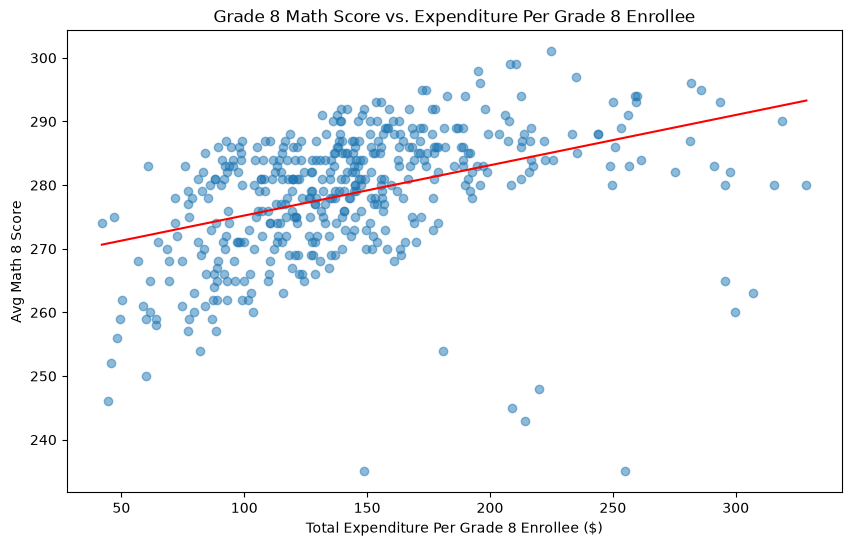

In [59]:
# @@@ 6

viz1_df = df[['Total Expenditure Per Grade 8 Enrollee', 'Avg Math 8 Score']].dropna()

plt.figure(figsize=(10,6))
plt.scatter(viz1_df['Total Expenditure Per Grade 8 Enrollee'], viz1_df['Avg Math 8 Score'], alpha=0.5)

# trend line
z = np.polyfit(viz1_df['Total Expenditure Per Grade 8 Enrollee'], viz1_df['Avg Math 8 Score'], 1)
p = np.poly1d(z)
x_line = np.linspace(viz1_df['Total Expenditure Per Grade 8 Enrollee'].min(),
                      viz1_df['Total Expenditure Per Grade 8 Enrollee'].max(), 100)
plt.plot(x_line, p(x_line), color='red')

plt.xlabel('Total Expenditure Per Grade 8 Enrollee ($)')
plt.ylabel('Avg Math 8 Score')
plt.title('Grade 8 Math Score vs. Expenditure Per Grade 8 Enrollee')
plt.show()


This scatterplot with a trend-line showing the relationship between total expenditure per grade 8 enrollee and average math 8 scores. The data shows that in general, students who receive a higher expenditure are expected to receive higher math 8 scores.

**Visualization 2**

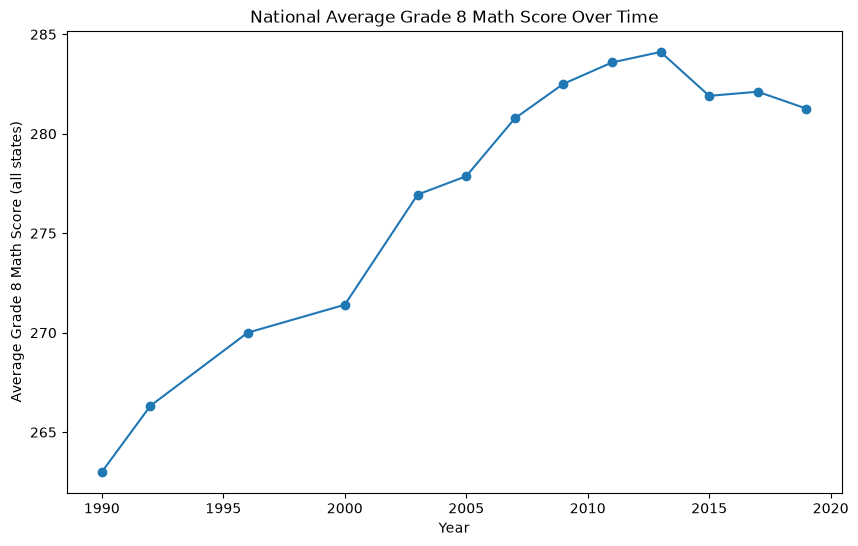

In [60]:
# @@@ 7

yearly_avg = df.groupby('Year')['Avg Math 8 Score'].mean().dropna()

plt.figure(figsize=(10,6))
plt.plot(yearly_avg.index, yearly_avg.values, marker='o')

plt.xlabel('Year')
plt.ylabel('Average Grade 8 Math Score (all states)')
plt.title('National Average Grade 8 Math Score Over Time')
plt.show()


This line graph shows the change in average annual grade 8 math scores over time. The graph shows that over the 30 year span, math scores increased in general, but has decreased from its peak in 2013 through the rest of the time window.

<h2> Data Creation </h2>

_Use this space to create train/test data_

In [61]:
from sklearn.model_selection import train_test_split

In [62]:
# @@@ 8

features = [
    'Total Expenditure Per Grade 8 Enrollee',
    'Instruction Expenditure',
    'Support Services Expenditure',
    'Enroll'
]

model_df = df[features + ['Avg Math 8 Score']].dropna()

X = model_df[features]
y = model_df['Avg Math 8 Score']


In [63]:
# @@@ 9

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


<h2> Prediction </h2>

ML Models [Resource](https://medium.com/@vijaya.beeravalli/comparison-of-machine-learning-classification-models-for-credit-card-default-data-c3cf805c9a5a)

In [64]:
# @@@ 10
from sklearn.ensemble import GradientBoostingRegressor


In [65]:
# @@@ 11

model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)


In [66]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [67]:
y_pred = model.predict(X_test)

y_pred

array([286.17873565, 288.07985348, 276.48101826, 270.04080492,
       285.19765508, 257.77142909, 276.93713323, 279.83969244,
       278.80462862, 280.36649853, 277.22487624, 282.78497392,
       280.03166798, 289.02372294, 291.27686303, 276.25482333,
       265.37588794, 290.27995083, 285.49230354, 279.83969244,
       279.42053479, 276.02908296, 281.22293001, 265.88794208,
       279.72447552, 284.3430889 , 280.12192903, 272.49966415,
       277.84449384, 275.07797267, 262.45490616, 280.53551054,
       284.08446394, 273.19185923, 279.40757163, 288.36428588,
       276.43409011, 271.50082288, 289.83142348, 273.56062879,
       282.72983464, 276.83011961, 274.95837772, 284.34053138,
       287.28659845, 272.21242759, 275.16454182, 281.11080682,
       283.2606316 , 274.16691528, 280.65468682, 285.67063223,
       282.6844947 , 284.28916378, 271.67706855, 284.35702856,
       282.57659911, 283.22993034, 283.75355422, 279.83969244,
       272.61117359, 279.91991026, 273.52477253, 273.10

## Evaluation

Choose some metrics to evaluate the performance of your model, some of them are mentioned in the tutorial.

In [71]:
# @@@ 12
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Training set:")
print(f"  MAE:  {mean_absolute_error(y_train, train_pred):.2f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_train, train_pred)):.2f}")
print(f"  R^2:  {r2_score(y_train, train_pred):.3f}")

print("\nTest set:")
print(f"  MAE:  {mean_absolute_error(y_test, test_pred):.2f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, test_pred)):.2f}")
print(f"  R^2:  {r2_score(y_test, test_pred):.3f}")


Training set:
  MAE:  2.38
  RMSE: 2.94
  R^2:  0.895

Test set:
  MAE:  5.61
  RMSE: 6.72
  R^2:  0.479


We have copied over the graphs that visualize the model's performance on the training and testing set. 

Change `col_name` and modify the call to `plt.ylabel()` to isolate how a single predictor affects the model.

Text(0.5, 1.0, 'Model Behavior On Training Set')

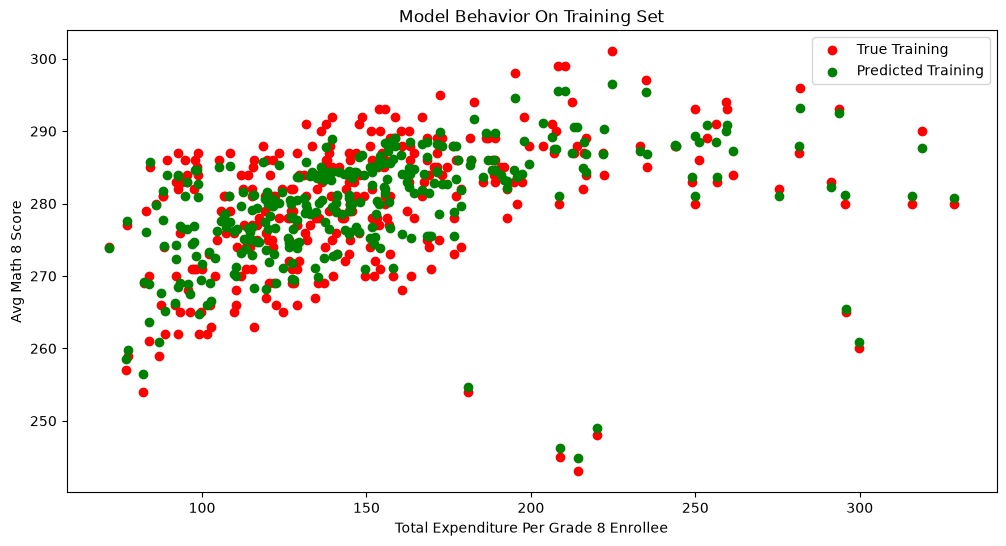

In [72]:
# @@@ 13

col_name = 'Total Expenditure Per Grade 8 Enrollee'

f = plt.figure(figsize=(12,6))
plt.scatter(X_train[col_name], y_train, color = "red")
plt.scatter(X_train[col_name], model.predict(X_train), color = "green")

plt.legend(['True Training','Predicted Training'])
plt.xlabel(col_name)
plt.ylabel('Avg Math 8 Score')
plt.title("Model Behavior On Training Set")

Text(0.5, 1.0, 'Model Behavior on Testing Set')

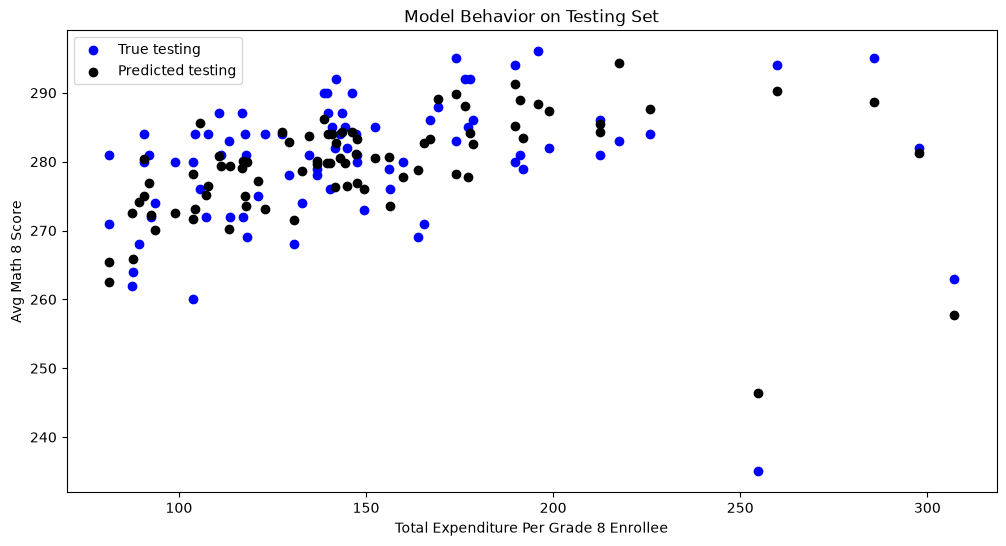

In [73]:
# @@@ 14

col_name = 'Total Expenditure Per Grade 8 Enrollee'

f = plt.figure(figsize=(12,6))
plt.scatter(X_test[col_name], y_test, color = "blue")
plt.scatter(X_test[col_name], model.predict(X_test), color = "black")

plt.legend(['True testing','Predicted testing'])
plt.xlabel(col_name)
plt.ylabel('Avg Math 8 Score')
plt.title("Model Behavior on Testing Set")